In [ ]:
#from keras.datasets import mnist
from keras.models import Sequential, Model
from keras.layers import Dense
import numpy as np
import h5py
from pathlib import Path
import matplotlib.pyplot as plt
import os

import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model


import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torchvision import datasets, models, transforms
import tensorflow as tf
from matplotlib import pyplot
import matplotlib.pyplot as plt
from matplotlib.image import imread
import time
import copy
from os import listdir
from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array
from os import makedirs
from tensorflow import keras

from shutil import copyfile
from random import seed
from random import random
from tqdm import tqdm
from PIL import Image

import pandas as pd
!pip install scanpy
import scanpy as sc #works

!pip install combat
!pip install combat --upgrade
from combat.pycombat import pycombat

!pip install --upgrade umap-learn
# !pip uninstall -y numba
# !pip install numba==0.56.4
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import umap

from google.colab import drive
drive.mount('/content/drive')

# !ls '/content/drive/MyDrive/'

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/all_plate_signals_plate16.csv')
df

,Unnamed: 0,File,Drugname,Dose,Well,Donor,Plate,Group,0,1,...,790,791,792,793,794,795,796,797,798,799
0,0,N-Nitrosopyrrolidine_100uM,N-Nitrosopyrrolidine,100.0,B2,1083,1,baseline,1584,1752,...,1846,1855,1837,1657,1444,1209,1088,1015,1001,961
1,1,Isoniazid_100uM,Isoniazid,100.0,B3,1083,1,baseline,1135,1015,...,950,946,937,938,932,933,938,907,925,942
2,2,Methotrexate_100uM,Methotrexate,100.0,B4,1083,1,baseline,858,852,...,880,880,876,874,886,894,883,885,886,886
3,3,2-Chloroethanol_100uM,2-Chloroethanol,100.0,B5,1083,1,baseline,922,930,...,931,934,933,927,921,933,947,936,941,941
4,4,Dicrotophos_100uM,Dicrotophos,100.0,B6,1083,1,baseline,783,775,...,1514,1452,1310,1072,914,861,829,812,800,789
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38803,38803,Pyrimethanil (Replicate)_0.1uM,Pyrimethanil (Replicate),0.1,O19,1434,16,treated,1179,1201,...,1792,2274,2429,2435,2371,2245,2085,1684,1442,1361
38804,38804,Coumarin (Replicate)_0.1uM,Coumarin (Replicate),0.1,O20,1434,16,treated,1294,1894,...,1347,1367,1380,1396,1535,2320,2582,2632,2633,2559
38805,38805,Fenthion (Replicate)_0.1uM,Fenthion (Replicate),0.1,O21,1434,16,treated,1311,1330,...,2739,2621,2506,2117,1787,1614,1551,1481,1440,1410
38806,38806,Chlorendic acid (Replicate)_0.1uM,Chlorendic acid (Replicate),0.1,O22,1434,16,treated,1569,1501,...,1750,1719,1701,1657,1596,1404,1214,1119,1117,1094


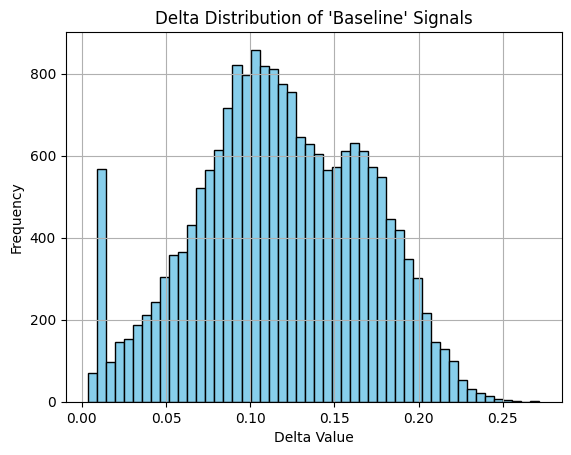

1th percentile delta: 0.0099
5th percentile delta: 0.0285
10th percentile delta: 0.0515
20th percentile delta: 0.0756
Number of noisy baseline signals removed: 1942


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/all_plate_signals_plate16.csv')
X = df.iloc[:, 207:607].to_numpy()  # Only signal portion
y = df['Group'].to_numpy()          # Labels

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

delta_values = X_scaled.max(axis=1) - X_scaled.min(axis=1)

baseline_deltas = delta_values[df['Group'] == 'baseline']
plt.hist(baseline_deltas, bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Delta Value")
plt.ylabel("Frequency")
plt.title("Delta Distribution of 'Baseline' Signals")
plt.grid(True)
plt.show()

for p in [1, 5, 10, 20]:
    val = np.percentile(baseline_deltas, p)
    print(f"{p}th percentile delta: {val:.4f}")


X = df.iloc[:, 207:607].to_numpy()
X = X.reshape(X.shape[0], -1)

y = df['Group'].to_numpy()

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

noise = []
for i, row in enumerate(X_scaled):
    delta = max(row) - min(row)
    if delta <= 0.0515 and y[i] == 'baseline':  # 10th percentile threshold
        noise.append(i)

print(f"Number of noisy baseline signals removed: {len(noise)}")

# Drop noisy rows and reset index
df = df.drop(noise).reset_index(drop=True)

In [ ]:
import pandas as pd
!pip install scanpy
import scanpy as sc

baseline_df = df[df['Group'] == 'baseline'].copy()
treated_df = df[df['Group'] == 'treated'].copy()

baseline_features = baseline_df.iloc[:, 8:808]
treated_features = treated_df.iloc[:, 8:808]

baseline_donors = baseline_df['Donor'].values.astype(int)

adata = sc.AnnData(baseline_features)
adata.obs['batch'] = baseline_donors

sc.pp.combat(adata, key='batch')

baseline_corrected = pd.DataFrame(adata.X, columns=baseline_features.columns, index=baseline_df.index)

treated_features_df = treated_features.copy()

filtered_df = pd.concat([baseline_corrected, treated_features_df], axis=0)

filtered_df['Donor'] = pd.concat([baseline_df['Donor'], treated_df['Donor']]).astype(int)
filtered_df['Group'] = pd.concat([baseline_df['Group'], treated_df['Group']])
filtered_df['Drugname'] = pd.concat([baseline_df['Drugname'], treated_df['Drugname']])
filtered_df['Dose'] = pd.concat([baseline_df['Dose'], treated_df['Dose']])
filtered_df['Plate'] = pd.concat([baseline_df['Plate'], treated_df['Plate']])
filtered_df['File'] = pd.concat([baseline_df['File'], treated_df['File']])

filtered_df.reset_index(drop=True, inplace=True)

filtered_df


/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


,0,1,2,3,4,5,6,7,8,9,...,796,797,798,799,Donor,Group,Drugname,Dose,Plate,File
0,1665.364762,1868.654816,1920.015491,1853.914457,1661.037444,1304.908780,1074.490930,995.819187,940.507442,910.874535,...,1050.314505,962.844654,947.038743,899.950151,1083,baseline,N-Nitrosopyrrolidine,100.0,1,N-Nitrosopyrrolidine_100uM
1,690.234491,679.077063,795.230429,1500.126556,1496.210918,1366.162928,1183.148589,907.246784,799.320989,737.772340,...,737.612706,718.008560,704.005686,691.514249,1083,baseline,Dicrotophos,100.0,1,Dicrotophos_100uM
2,833.886641,816.663845,823.198057,831.455266,852.777000,840.602343,836.184927,835.896792,841.063071,849.052322,...,845.066220,822.938315,837.008851,847.841175,1083,baseline,Safrole,100.0,1,Safrole_100uM
3,921.538800,921.375909,928.988652,943.305736,939.463543,933.708647,951.016317,952.763158,949.101400,961.568749,...,941.653649,938.722871,963.966418,985.990552,1083,baseline,Triethylene glycol bis(2-ethylhexanoate),100.0,1,Triethylene glycol bis(2-ethylhexanoate)_100uM
4,824.147512,805.705606,812.254202,829.023734,825.916381,847.952840,842.358658,842.047653,826.330571,834.214991,...,839.029506,839.823562,839.427091,849.053012,1083,baseline,2-Chloro-4-phenylphenol,100.0,1,2-Chloro-4-phenylphenol_100uM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36861,1179.000000,1201.000000,1213.000000,1204.000000,1189.000000,1337.000000,2212.000000,2434.000000,2426.000000,2342.000000,...,2085.000000,1684.000000,1442.000000,1361.000000,1434,treated,Pyrimethanil (Replicate),0.1,16,Pyrimethanil (Replicate)_0.1uM
36862,1294.000000,1894.000000,2398.000000,2554.000000,2609.000000,2570.000000,2504.000000,2440.000000,2174.000000,1780.000000,...,2582.000000,2632.000000,2633.000000,2559.000000,1434,treated,Coumarin (Replicate),0.1,16,Coumarin (Replicate)_0.1uM
36863,1311.000000,1330.000000,1340.000000,2295.000000,2647.000000,2793.000000,2750.000000,2742.000000,2523.000000,2220.000000,...,1551.000000,1481.000000,1440.000000,1410.000000,1434,treated,Fenthion (Replicate),0.1,16,Fenthion (Replicate)_0.1uM
36864,1569.000000,1501.000000,1287.000000,1154.000000,1108.000000,1081.000000,1092.000000,1086.000000,1072.000000,1074.000000,...,1214.000000,1119.000000,1117.000000,1094.000000,1434,treated,Chlorendic acid (Replicate),0.1,16,Chlorendic acid (Replicate)_0.1uM


In [ ]:
baseline_df = filtered_df[filtered_df['Group'] == 'baseline']
treated_df = filtered_df[filtered_df['Group'] == 'treated']
print(len(baseline_df))
print(len(treated_df))

X_baseline=baseline_df.iloc[:, 207:607].to_numpy() # just the signal
X_baseline = X_baseline.reshape(X_baseline.shape[0], -1)
y_baseline =baseline_df['Group'].to_numpy() # for our labels

X_treated =treated_df.iloc[:, 207:607].to_numpy() # just the signal
X_treated = X_treated.reshape(X_treated.shape[0], -1)
y_treated =treated_df['Group'].to_numpy() # for our labels

from sklearn import preprocessing
min_max_scaler = preprocessing.MinMaxScaler()
X_baseline = min_max_scaler.fit_transform(X_baseline)
X_treated = min_max_scaler.fit_transform(X_treated)

original_indices = np.arange(len(X_baseline))

train_data, test_data, train_labels, test_labels, train_indices, test_indices = train_test_split(
    X_baseline, y_baseline, original_indices, test_size=0.3, random_state=123
)

min_val = tf.reduce_min(train_data)
max_val = tf.reduce_max(train_data)

train_data = (train_data - min_val) / (max_val - min_val)
test_data = (test_data - min_val) / (max_val - min_val)

train_data = tf.cast(train_data, tf.float32)

17462
19404


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

class AutoencoderSimple(Model):
  def __init__(self):
    super(AutoencoderSimple, self).__init__()
    self.encoder = tf.keras.Sequential([
      layers.Dense(400, activation="tanh"),
      layers.Dropout(0.2),
      layers.Dense(272, activation="tanh"),
      layers.Dropout(0.2),
      layers.Dense(136, activation="tanh"),
      layers.Dropout(0.2),
      layers.Dense(72, activation="tanh"),
      layers.Dropout(0.2),
      layers.Dense(32, activation="tanh"),
      layers.Dropout(0.2),
      layers.Dense(12, activation="tanh"),
      ])

    self.decoder = tf.keras.Sequential([
      layers.Dense(32, activation="tanh"),
      layers.Dropout(0.2),
      layers.Dense(72, activation="tanh"),
      layers.Dropout(0.2),
      layers.Dense(136, activation="tanh"),
      layers.Dropout(0.2),
      layers.Dense(272, activation="tanh"),
      layers.Dropout(0.2),
      layers.Dense(400, activation="sigmoid")])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

autoencoder = AutoencoderSimple()
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder(tf.zeros((1, 400)))

# loading saved weights
autoencoder.load_weights("/content/drive/MyDrive/autoencoder.weights.h5")

print("Weights loaded!")

encoded_data = autoencoder.encoder(test_data).numpy()
decoded_data = autoencoder.decoder(encoded_data).numpy()


 Weights loaded successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
import numpy as np

reconstruction_error = np.mean((test_data - decoded_data)**2, axis=1)  # per sample
mean_error = np.mean(reconstruction_error)  # overall average
print("Mean reconstruction error:", mean_error)


Mean reconstruction error: 0.006324638178444231


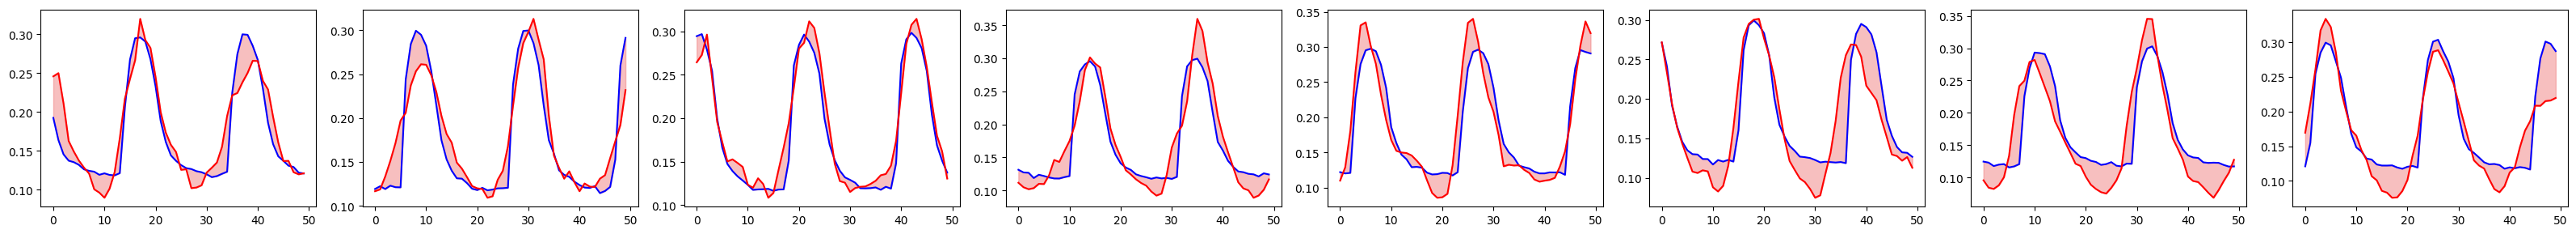

np.float64(0.17016905994739004)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

def window_nrmse_plot(donor, drugname, dose, plate, window_size):
    # Find the matching row
    row = treated_df[
        (treated_df["Donor"] == donor) &
        (treated_df["Drugname"] == drugname) &
        (treated_df["Dose"] == dose) &
        (treated_df["Plate"] == plate)
    ].iloc[0]

    row_idx = treated_df.index.get_loc(row.name)

    encoded_data = autoencoder.encoder(X_treated).numpy()
    decoded_data = autoencoder.decoder(encoded_data).numpy()

    signal = X_treated[row_idx]
    reconstructed = decoded_data[row_idx]

    n_windows = signal.shape[0] // window_size
    nrmse = []

    #this is for the plots
    n_cols = 8
    n_rows = int(np.ceil(n_windows / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
    axes = axes.flatten()

    for i in range(n_windows):
        start = i * window_size
        end = start + window_size

        #nrmse
        rmse = np.sqrt(mean_squared_error(signal[start:end], reconstructed[start:end]))
        window_range = np.max(signal[start:end]) - np.min(signal[start:end])
        normalized_rmse = rmse / window_range
        nrmse.append(normalized_rmse)

        ax = axes[i]
        ax.plot(np.arange(window_size), signal[start:end], 'b', label="Input")
        ax.plot(np.arange(window_size), reconstructed[start:end], 'r', label="Reconstruction")
        ax.fill_between(np.arange(window_size), reconstructed[start:end], signal[start:end], color='lightcoral', alpha=0.5)


    handles, labels = axes[0].get_legend_handles_labels()

    plt.tight_layout()
    plt.show()

    avg_nrmse = np.mean(nrmse)
    return avg_nrmse

window_nrmse_plot(1434, "VEH", 1.0, 16, 50)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

donors = [1083, 1368, 1392, 1434]
doses = [0.1, 1.0, 10.0, 100.0]

def window_nrmse_plot_full_signal(drugname, plate, window_size):
    encoded_data = autoencoder.encoder(X_treated).numpy()
    decoded_data = autoencoder.decoder(encoded_data).numpy()

    n_rows = len(doses)
    n_cols = len(donors)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows), sharex=True, sharey=True)

    for r, dose in enumerate(doses):
        for c, donor in enumerate(donors):
            ax = axes[r, c]

            filtered = treated_df[
                (treated_df["Donor"] == donor) &
                (treated_df["Drugname"] == drugname) &
                (treated_df["Dose"] == dose) &
                (treated_df["Plate"] == plate)
            ]

            if filtered.empty:
                ax.axis('off')  # leave blank if no data
                continue

            row = filtered.iloc[0]
            row_idx = treated_df.index.get_loc(row.name)
            signal = X_treated[row_idx]
            reconstructed = decoded_data[row_idx]

            # windowed NRMSE using per-window normalization
            n_windows = signal.shape[0] // window_size
            nrmse = []
            for w in range(n_windows):
                start = w * window_size
                end = start + window_size
                rmse = np.sqrt(mean_squared_error(signal[start:end], reconstructed[start:end]))
                window_range = np.max(signal[start:end]) - np.min(signal[start:end])
                normalized_rmse = rmse / window_range
                nrmse.append(normalized_rmse)

            avg_nrmse = np.mean(nrmse)

            # plot full signal
            ax.plot(signal, 'b', label="Input")
            ax.plot(reconstructed, 'r', label="Reconstruction")
            ax.set_title(f"Donor {donor} | Dose {dose} µM\nNRMSE={avg_nrmse:.3f}", fontsize=10)
            #ax.set_xlabel("Time points")
            #ax.set_ylabel("Fluorescence (a.u.)")


    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower right")
    plt.tight_layout()
    plt.show()

window_nrmse_plot_full_signal("VEH", 11, 50)


now continuing

In [ ]:
def window_nrmse_all(insert_data, window_size):

    encoded_data = autoencoder.encoder(insert_data).numpy()
    decoded_data = autoencoder.decoder(encoded_data).numpy()

    all_avg_nrmse = []

    for x in range(len(insert_data)):
        signal = insert_data[x]
        reconstructed = decoded_data[x]

        n_windows = signal.shape[0] // window_size
        nrmse_per_signal = []

        for w in range(n_windows):
            start = w * window_size
            end = start + window_size

            rmse = np.sqrt(mean_squared_error(signal[start:end], reconstructed[start:end]))
            window_range = np.max(signal[start:end]) - np.min(signal[start:end])
            normalized_rmse = rmse / window_range
            nrmse_per_signal.append(normalized_rmse)

        avg_nrmse = np.mean(nrmse_per_signal)
        all_avg_nrmse.append(avg_nrmse)

    return all_avg_nrmse

avg_nrmse = window_nrmse_all(X_treated, 50)
avg_nrmse

/tmp/ipykernel_2708/2526773911.py:21: RuntimeWarning: divide by zero encountered in scalar divide
  normalized_rmse = rmse / window_range
/tmp/ipykernel_2708/2526773911.py:21: RuntimeWarning: divide by zero encountered in scalar divide
  normalized_rmse = rmse / window_range
/tmp/ipykernel_2708/2526773911.py:21: RuntimeWarning: divide by zero encountered in scalar divide
  normalized_rmse = rmse / window_range
/tmp/ipykernel_2708/2526773911.py:21: RuntimeWarning: divide by zero encountered in scalar divide
  normalized_rmse = rmse / window_range
/tmp/ipykernel_2708/2526773911.py:21: RuntimeWarning: divide by zero encountered in scalar divide
  normalized_rmse = rmse / window_range
/tmp/ipykernel_2708/2526773911.py:21: RuntimeWarning: divide by zero encountered in scalar divide
  normalized_rmse = rmse / window_range
/tmp/ipykernel_2708/2526773911.py:21: RuntimeWarning: divide by zero encountered in scalar divide
  normalized_rmse = rmse / window_range
/tmp/ipykernel_2708/2526773911.py:

[np.float64(0.8833225273421044),
 np.float64(0.38252833524468544),
 np.float64(0.367930852141584),
 np.float64(0.38028032669510126),
 np.float64(0.3679854582963452),
 np.float64(0.38896635955900205),
 np.float64(0.8620242662262296),
 np.float64(1.2185930778336522),
 np.float64(0.9362942998902375),
 np.float64(0.36972116843160435),
 np.float64(0.818950096761077),
 np.float64(0.31358994933489226),
 np.float64(0.38304893993997313),
 np.float64(0.21955723430035542),
 np.float64(1.2023273929892637),
 np.float64(0.25470441047780845),
 np.float64(0.8479519304745184),
 np.float64(1.0638460812535935),
 np.float64(0.38005509731006365),
 np.float64(0.34853137275308),
 np.float64(0.769990833703146),
 np.float64(1.1579531814382622),
 np.float64(0.7819024501059961),
 np.float64(0.2487415267272335),
 np.float64(0.3689382942411005),
 np.float64(0.3659831764526813),
 np.float64(0.22338848480562312),
 np.float64(0.3599130760834729),
 np.float64(0.38361051562906545),
 np.float64(0.3769535612464144),
 np.

In [ ]:
nrmse_df = pd.DataFrame(avg_nrmse, columns = ['nrmse'])
len(nrmse_df)

treated_labels = treated_df.iloc[:,800:].reset_index()
treated_labels.drop('index', axis=1, inplace=True)
treated_labels
treated_sig = pd.DataFrame(X_treated)
treated_sig
treated_er_df = pd.concat([treated_labels,nrmse_df,treated_sig], axis = 1)
treated_er_df

,Donor,Group,Drugname,Dose,Plate,File,nrmse,0,1,2,...,390,391,392,393,394,395,396,397,398,399
0,1083,treated,N-Nitrosopyrrolidine,100.0,1,N-Nitrosopyrrolidine_100uM,0.883323,0.107489,0.109470,0.109829,...,0.112885,0.108413,0.109955,0.112410,0.110986,0.113338,0.110817,0.108405,0.108299,0.109057
1,1083,treated,Isoniazid,100.0,1,Isoniazid_100uM,0.382528,0.157030,0.120418,0.100317,...,0.188973,0.194792,0.183049,0.163460,0.121598,0.104195,0.097185,0.093387,0.091424,0.145535
2,1083,treated,Methotrexate,100.0,1,Methotrexate_100uM,0.367931,0.203388,0.192974,0.151554,...,0.197954,0.164872,0.125251,0.109896,0.102871,0.100438,0.195128,0.206335,0.176552,0.133836
3,1083,treated,2-Chloroethanol,100.0,1,2-Chloroethanol_100uM,0.380280,0.115257,0.106034,0.098668,...,0.131845,0.112293,0.104313,0.100591,0.098502,0.160426,0.206235,0.206209,0.184989,0.148050
4,1083,treated,Dicrotophos,100.0,1,Dicrotophos_100uM,0.367985,0.150790,0.112398,0.087127,...,0.168143,0.137832,0.100050,0.084245,0.080275,0.073638,0.073962,0.088213,0.172648,0.163774
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19399,1434,treated,Pyrimethanil (Replicate),0.1,16,Pyrimethanil (Replicate)_0.1uM,0.164682,0.115767,0.112907,0.105390,...,0.136709,0.122183,0.115722,0.110273,0.105119,0.106324,0.102739,0.104366,0.098854,0.100629
19400,1434,treated,Coumarin (Replicate),0.1,16,Coumarin (Replicate)_0.1uM,0.188659,0.276872,0.274440,0.252124,...,0.117001,0.118302,0.117979,0.117817,0.126592,0.236443,0.272245,0.277007,0.274651,0.270063
19401,1434,treated,Fenthion (Replicate),0.1,16,Fenthion (Replicate)_0.1uM,0.201158,0.295848,0.312245,0.298668,...,0.124361,0.251878,0.289117,0.304665,0.289638,0.280776,0.266566,0.228672,0.173152,0.158113
19402,1434,treated,Chlorendic acid (Replicate),0.1,16,Chlorendic acid (Replicate)_0.1uM,0.381908,0.083291,0.085794,0.081674,...,0.077585,0.081247,0.145311,0.165724,0.167541,0.167815,0.165089,0.156613,0.148092,0.127799


In [ ]:
high_tdp_drugs = ['Bepridil','Dofetilide','Quinidine','D,1 Sotalol','Azimilide','Vandetanib','Disopyramide']

def threshold_value(drug):
  b = treated_er_df[(treated_er_df['Drugname'] == drug) & (treated_er_df['Dose'].isin([100.0]))]
  Q1 = b['nrmse'].quantile(0.25)
  Q3 = b['nrmse'].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  b.drop(b[(b['nrmse'] < lower_bound) | (b['nrmse'] > upper_bound)].index, inplace=True)
  print(b.nrmse.min())
  return b.nrmse

cipa_100_min =[]

for drug in high_tdp_drugs:
  print(drug)
  #threshold_value(drug)
  cipa_100_min.append(threshold_value(drug).min())

Bepridil
0.9322114527860998
Dofetilide
0.27661562780308807
Quinidine
0.41833099795475737
D,1 Sotalol
0.29847966508639
Azimilide
0.9711774573243332
Vandetanib
0.9612189641040703
Disopyramide
0.3289614118489079


/tmp/ipykernel_2708/2725125836.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b.drop(b[(b['nrmse'] < lower_bound) | (b['nrmse'] > upper_bound)].index, inplace=True)
/tmp/ipykernel_2708/2725125836.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b.drop(b[(b['nrmse'] < lower_bound) | (b['nrmse'] > upper_bound)].index, inplace=True)
/tmp/ipykernel_2708/2725125836.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b.drop(b[(b['

In [ ]:
b = treated_er_df[treated_er_df['Drugname'] == 'TAB']
Q1 = b['nrmse'].quantile(0.25)
Q3 = b['nrmse'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
b.drop(b[(b['nrmse'] < lower_bound) | (b['nrmse'] > upper_bound)].index, inplace=True)
TAB = b

b = treated_er_df[treated_er_df['Drugname'] == 'ISO']
Q1 = b['nrmse'].quantile(0.25)
Q3 = b['nrmse'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
b.drop(b[(b['nrmse'] < lower_bound) | (b['nrmse'] > upper_bound)].index, inplace=True)
ISO = b

b = treated_er_df[treated_er_df['Drugname'] == 'PRO']
Q1 = b['nrmse'].quantile(0.25)
Q3 = b['nrmse'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
b.drop(b[(b['nrmse'] < lower_bound) | (b['nrmse'] > upper_bound)].index, inplace=True)
PRO = b

b = treated_er_df[treated_er_df['Drugname'] == 'CIS']
Q1 = b['nrmse'].quantile(0.25)
Q3 = b['nrmse'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
b.drop(b[(b['nrmse'] < lower_bound) | (b['nrmse'] > upper_bound)].index, inplace=True)
CIS = b

b = treated_er_df[treated_er_df['Drugname'] == 'VEH']
Q1 = b['nrmse'].quantile(0.25)
Q3 = b['nrmse'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
b.drop(b[(b['nrmse'] < lower_bound) | (b['nrmse'] > upper_bound)].index, inplace=True)
VEH = b

b = treated_er_df[treated_er_df['Drugname'] == 'MEDIA']
Q1 = b['nrmse'].quantile(0.25)
Q3 = b['nrmse'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
b.drop(b[(b['nrmse'] < lower_bound) | (b['nrmse'] > upper_bound)].index, inplace=True)
MEDIA = b

# HIGHLY TOXIC group: High TdP + TAB
print("High TdP individual NRMSEs:", cipa_100_min)
print("TAB min NRMSE:", TAB.nrmse.min())

high_tdp_tab_mean = np.mean(cipa_100_min + [TAB.nrmse.min()])
print("High TdP + TAB mean:", high_tdp_tab_mean)

# MEDIUM toxicity group: ISO, PRO, CIS
print("ISO max NRMSE:", ISO.nrmse.max())
print("PRO max NRMSE:", PRO.nrmse.max())
print("CIS max NRMSE:", CIS.nrmse.max())

medium_toxicity_max = np.mean([ISO.nrmse.max(), PRO.nrmse.max(), CIS.nrmse.max()])
print("Medium toxicity mean (ISO, PRO, CIS):", medium_toxicity_max)

# Category 2 threshold: average of the two group summaries
category2_threshold = np.mean([high_tdp_tab_mean, medium_toxicity_max])
print("Category 2 Threshold:", category2_threshold)

# MEDIUM toxicity group: ISO, PRO, CIS
print("ISO mean NRMSE:", ISO.nrmse.mean())
print("PRO mean NRMSE:", PRO.nrmse.mean())
print("CIS mean NRMSE:", CIS.nrmse.mean())

medium_toxicity_mean = np.mean([ISO.nrmse.mean(), PRO.nrmse.mean(), CIS.nrmse.mean()])
print("Medium toxicity mean (ISO, PRO, CIS):", medium_toxicity_mean)

# Baseline group: VEH, MEDIA
print("VEH mean NRMSE:", VEH.nrmse.mean())
print("MEDIA mean NRMSE:", MEDIA.nrmse.mean())

baseline_mean = np.mean([VEH.nrmse.mean(), MEDIA.nrmse.mean()])
print("Baseline mean (VEH, MEDIA):", baseline_mean)

# Category 1 threshold: average of the two group summaries
category1_threshold = np.mean([medium_toxicity_mean, baseline_mean])
print("Category 1 Threshold:", category1_threshold)



High TdP individual NRMSEs: [0.9322114527860998, 0.27661562780308807, 0.41833099795475737, 0.29847966508639, 0.9711774573243332, 0.9612189641040703, 0.3289614118489079]
TAB min NRMSE: 0.8508234649098021
High TdP + TAB mean: 0.6297273802271811
ISO max NRMSE: 0.44853656452443935
PRO max NRMSE: 0.44822255161645697
CIS max NRMSE: 0.4857788858668475
Medium toxicity mean (ISO, PRO, CIS): 0.4608460006692479
Category 2 Threshold: 0.5452866904482145
ISO mean NRMSE: 0.3360237079206869
PRO mean NRMSE: 0.2775523747593442
CIS mean NRMSE: 0.286048319987837
Medium toxicity mean (ISO, PRO, CIS): 0.29987480088928936
VEH mean NRMSE: 0.27017838404463457
MEDIA mean NRMSE: 0.29129924199854385
Baseline mean (VEH, MEDIA): 0.2807388130215892
Category 1 Threshold: 0.2903068069554393


/tmp/ipykernel_2708/3477409253.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b.drop(b[(b['nrmse'] < lower_bound) | (b['nrmse'] > upper_bound)].index, inplace=True)
/tmp/ipykernel_2708/3477409253.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b.drop(b[(b['nrmse'] < lower_bound) | (b['nrmse'] > upper_bound)].index, inplace=True)
/tmp/ipykernel_2708/3477409253.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b.drop(b[(b['n

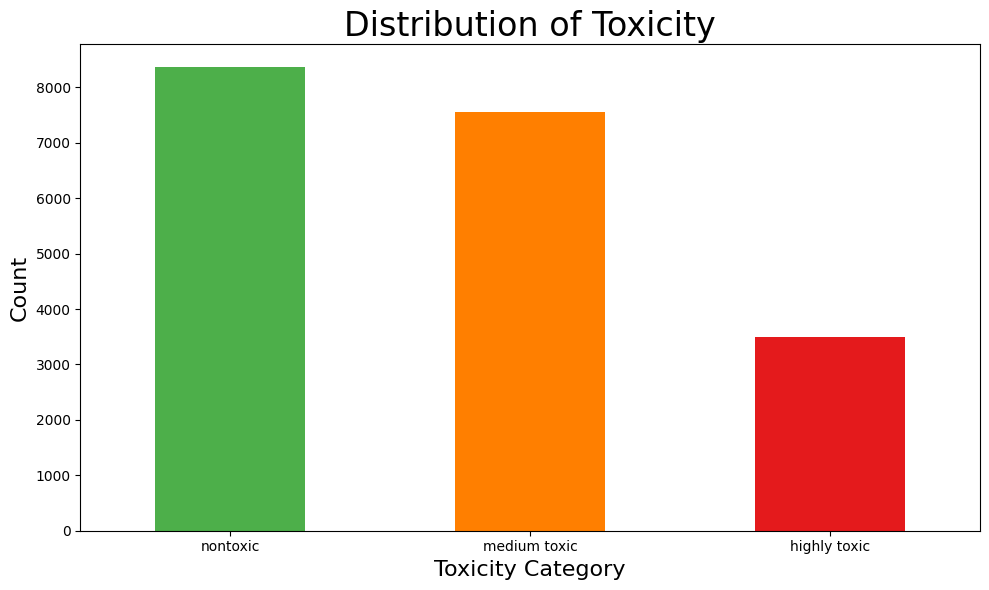

In [ ]:
treated_er_df['toxicity'] = np.where(treated_er_df.nrmse < category1_threshold, 'nontoxic',
                                      np.where((treated_er_df.nrmse > category1_threshold) & (treated_er_df.nrmse < category2_threshold),
                                               'medium toxic', 'highly toxic'))

#distribution of donors before data cleaning
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

toxicity_map = {
    'nontoxic': 2,
    'medium toxic': 4,
    'highly toxic': 0,
}

default_color_index = 2

color_palette = 'Set1'

palette = sns.color_palette(color_palette)

toxicity_counts = treated_er_df['toxicity'].value_counts()

plt.figure(figsize=(10, 6))
colors = [palette[toxicity_map.get(str(toxicity), default_color_index)] for toxicity in toxicity_counts.index]
toxicity_counts.plot(kind='bar', color=colors)
plt.xlabel('Toxicity Category', fontsize = 16)
plt.ylabel('Count', fontsize = 16)
plt.title('Distribution of Toxicity',fontsize = 24)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
toxicity_counts

,count
toxicity,
nontoxic,8357
medium toxic,7561
highly toxic,3486


IC50s from multi donor voting system

In [ ]:
df = treated_er_df.copy()

toxicity_map = {
    "nontoxic": 0,
    "medium toxic": 1,
    "highly toxic": 2
}
df['toxicity_score'] = df['toxicity'].map(toxicity_map)

donor_counts = df.groupby(['Drugname', 'Dose'])['Donor'].nunique().reset_index()
donor_counts.rename(columns={'Donor': 'num_donors'}, inplace=True)

# Aggregate sum of toxicity votes per drug-dose
agg_df = (
    df.groupby(['Drugname', 'Dose'])
      .agg(vote_sum=('toxicity_score', 'sum'))
      .reset_index()
)
agg_df = agg_df.merge(donor_counts, on=['Drugname', 'Dose'], how='left')

valid_drugs = (
    agg_df.groupby('Drugname')['Dose']
    .nunique()
    .reset_index()
    .query('Dose >= 2')['Drugname']
)
valid_drugs = valid_drugs[valid_drugs != 'VEH']  # remove 'VEH'

# Filter valid and invalid dataframes
valid_df = agg_df[agg_df['Drugname'].isin(valid_drugs)]
valid_df['fraction infectivity'] = valid_df['vote_sum'] / (valid_df['num_donors'] * 2)

invalid_df = agg_df[~agg_df['Drugname'].isin(valid_drugs)]

/tmp/ipykernel_2708/4216171994.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_df['fraction infectivity'] = valid_df['vote_sum'] / (valid_df['num_donors'] * 2)


,Drugname,Dose,vote_sum,num_donors,fraction infectivity
0,(-)-Epigallocatechin gallate,0.1,1,4,0.125
1,(-)-Epigallocatechin gallate,1.0,2,4,0.250
2,(-)-Epigallocatechin gallate,10.0,1,4,0.125
3,(-)-Epigallocatechin gallate,100.0,8,4,1.000
4,"(2Z)-3,7-Dimethylocta-2,6-dien-1-ol",0.1,3,4,0.375


/tmp/ipykernel_2708/2221693256.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(DRC, x, y, p0=p0, bounds=(lb, ub), maxfev=50000) # inclrease maxfev if you want there to be more overfitting


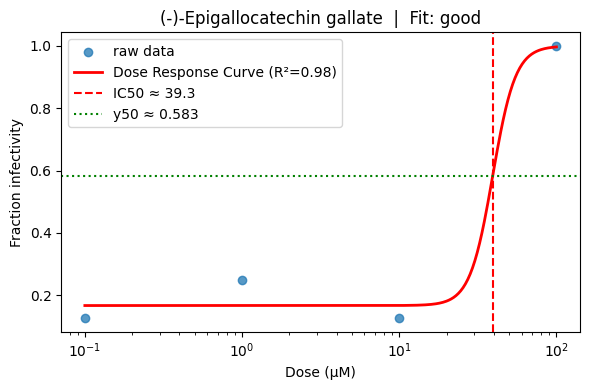

/tmp/ipykernel_2708/2221693256.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(DRC, x, y, p0=p0, bounds=(lb, ub), maxfev=50000) # inclrease maxfev if you want there to be more overfitting


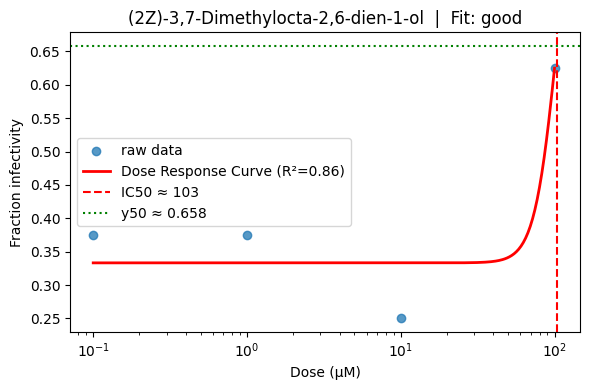

/tmp/ipykernel_2708/2221693256.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(DRC, x, y, p0=p0, bounds=(lb, ub), maxfev=50000) # inclrease maxfev if you want there to be more overfitting


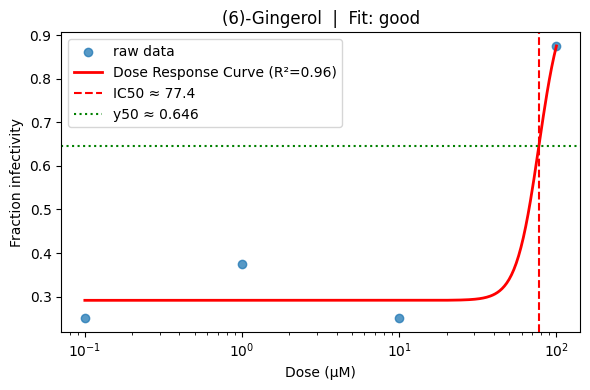

/tmp/ipykernel_2708/2221693256.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(DRC, x, y, p0=p0, bounds=(lb, ub), maxfev=50000) # inclrease maxfev if you want there to be more overfitting


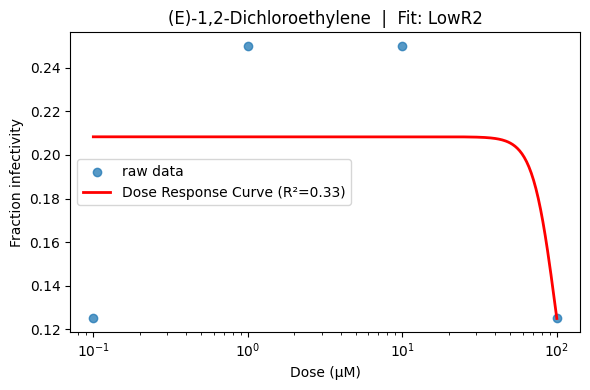

/tmp/ipykernel_2708/2221693256.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(DRC, x, y, p0=p0, bounds=(lb, ub), maxfev=50000) # inclrease maxfev if you want there to be more overfitting


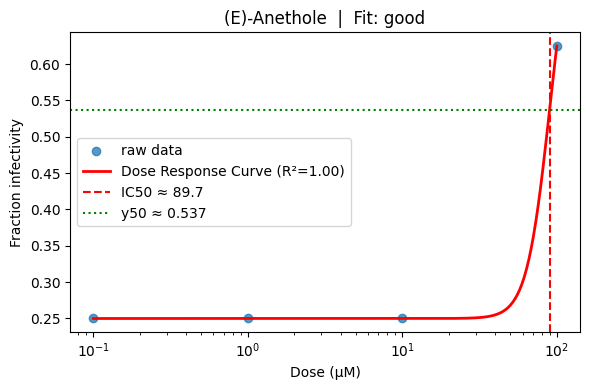

/tmp/ipykernel_2708/2221693256.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(DRC, x, y, p0=p0, bounds=(lb, ub), maxfev=50000) # inclrease maxfev if you want there to be more overfitting


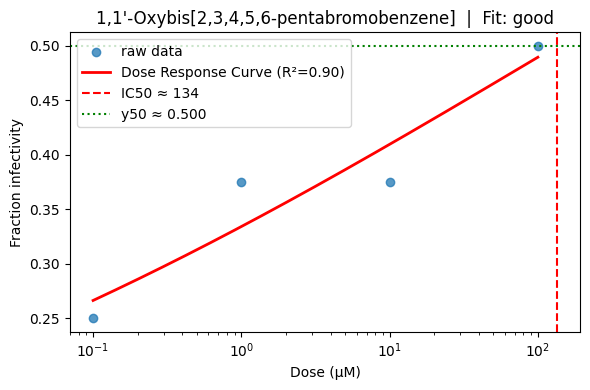

/tmp/ipykernel_2708/2221693256.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(DRC, x, y, p0=p0, bounds=(lb, ub), maxfev=50000) # inclrease maxfev if you want there to be more overfitting


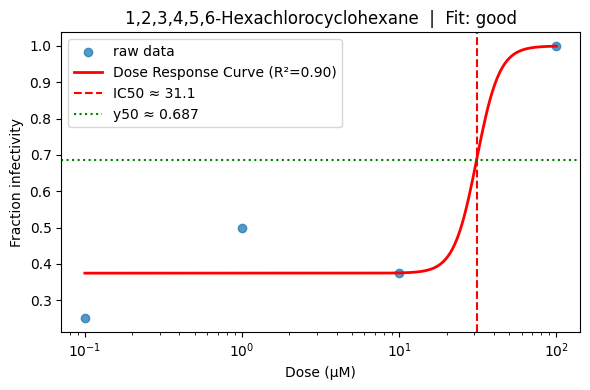

/tmp/ipykernel_2708/2221693256.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(DRC, x, y, p0=p0, bounds=(lb, ub), maxfev=50000) # inclrease maxfev if you want there to be more overfitting


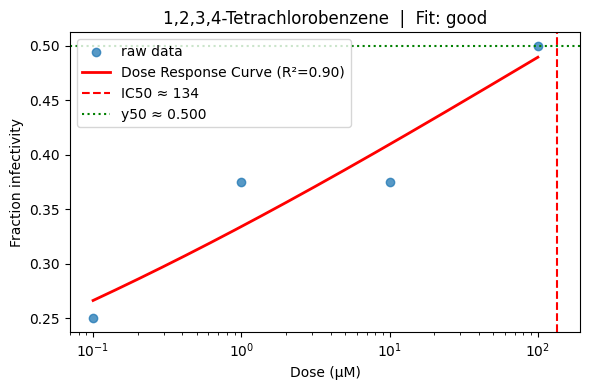

/tmp/ipykernel_2708/2221693256.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(DRC, x, y, p0=p0, bounds=(lb, ub), maxfev=50000) # inclrease maxfev if you want there to be more overfitting


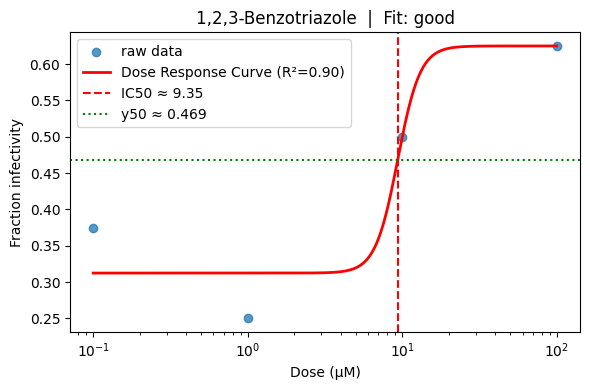

/tmp/ipykernel_2708/2221693256.py:137: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(DRC, x, y, p0=p0, bounds=(lb, ub), maxfev=50000) # inclrease maxfev if you want there to be more overfitting


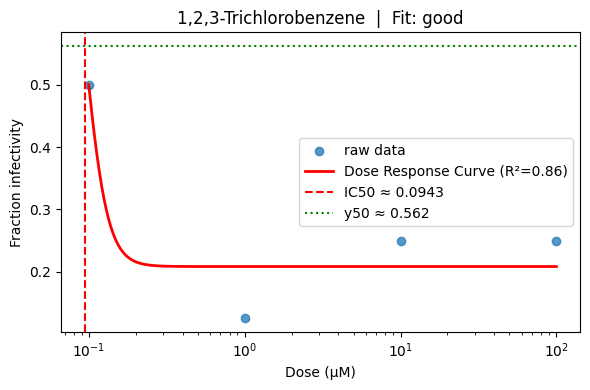

,Drugname,IC50,y50,Bottom,Top,Hill,log10IC50,R2,FitQuality,N_PositiveDoses
0,(-)-Epigallocatechin gallate,39.324673,0.583300,1.665991e-01,1.000000,-5.999659,1.594665,0.980339,good,4
1,"(2Z)-3,7-Dimethylocta-2,6-dien-1-ol",103.484895,0.658275,3.333332e-01,0.983218,-6.000000,2.014877,0.859648,good,4
2,(6)-Gingerol,77.357003,0.645833,2.916657e-01,1.000000,-6.000000,1.888500,0.960783,good,4
3,"(E)-1,2-Dichloroethylene",98.142473,0.129372,5.040995e-02,0.208333,5.908164,1.991857,0.333332,LowR2,4
4,(E)-Anethole,89.687626,0.536693,2.499995e-01,0.823386,-5.850148,1.952733,1.000000,good,4
5,"1,1'-Oxybis[2,3,4,5,6-pentabromobenzene]",134.243785,0.500000,1.069621e-22,1.000000,-0.140550,2.127894,0.896276,good,4
6,"1,2,3,4,5,6-Hexachlorocyclohexane",31.089544,0.687385,3.747698e-01,1.000000,-6.000000,1.492614,0.903612,good,4
7,"1,2,3,4-Tetrachlorobenzene",134.243785,0.500000,1.069621e-22,1.000000,-0.140550,2.127894,0.896276,good,4
8,"1,2,3-Benzotriazole",9.346564,0.468750,3.124999e-01,0.625000,-6.000000,0.970652,0.899999,good,4
9,"1,2,3-Trichlorobenzene",0.094257,0.562118,2.083334e-01,0.915903,6.000000,-1.025684,0.859648,good,4


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from google.colab import drive
import pandas as pd


df = valid_df.copy()
resp_col = "fraction infectivity"
display(df.head())


################################################################################
# functions for the for loop - dose response curve + IC50 and a few helper functions like rsquared
################################################################################

#def standard DRC w/ hill eq and using scipy to curve fit our defined fn -
#log IC50 will be the log-dose at half max response for IC50
def DRC(x, bottom, top, logIC50, hill):
  # returns hill eq
    IC50 = 10**logIC50
    return bottom + (top - bottom) / (1 + (x / IC50)**hill)  #top for max asympotote and min for bottom for normal hill eq

def initial_guess(x, y):

    bottom0 = float(np.nanmin(y))
    top0 = float(np.nanmax(y))
    x_pos = x[x > 0]
    logIC50_0 = np.log10(np.sqrt(np.min(x_pos) * np.max(x_pos))) if len(x_pos) else 0.0
    # Trend sign in log-dose space
    if len(x_pos) >= 2:
        trend = np.corrcoef(np.log10(x_pos), y[x > 0])[0, 1]
    else:
        trend = -0.5  # If response increases with dose, it'll be a negative hill for increasing curves
    hill0 = -1.0 if (trend > 0) else 1.0
    return [bottom0, top0, logIC50_0, hill0]

def data_bounds(x, y):

    y_low, y_high = 0.0, 1.0
    x_pos = x[x > 0]
    if len(x_pos) >= 2:
        low_log = np.log10(np.min(x_pos)) - 2.0
        high_log = np.log10(np.max(x_pos)) + 2.0
    else:
        low_log, high_log = -12.0, 12.0
    return ([y_low, y_low, low_log, -6.0],
            [y_high, y_high, high_log,  6.0])

def r_squared(y_true, y_pred):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() < 2:
        return np.nan #
    ss_res = np.sum((y_true[m] - y_pred[m])**2) # residual sum of squares
    ss_tot = np.sum((y_true[m] - np.mean(y_true[m]))**2) # all sum of squares from mean
    if ss_tot == 0:
        return np.nan
    return 1.0 - ss_res / ss_tot

def validate_fit(x, y, popt, r2, min_range=0.09, r2_min=0.70):
    if not np.all(np.isfinite(popt)):
        return False, "Failed to fit for data"
    bottom, top, logIC50, hill = popt
    IC50 = 10**logIC50

    # 1) Dynamic range
    if abs(top - bottom) < min_range:
        return False, "Flat - little difference"

    # 2) Hill sign consistent with overall trend
    x_pos = x[x > 0]; y_pos = y[x > 0]
    if len(x_pos) >= 2:
        trend = np.corrcoef(np.log10(x_pos), y_pos)[0, 1]
        if np.sign(trend) == np.sign(hill):
            return False, "BadSlope"

    # 3) IC50 in a sensible range
    if len(x_pos):
        lo, hi = np.min(x_pos), np.max(x_pos)
        if (IC50 < lo/10.0) or (IC50 > hi*10.0):
            return False, "Out of realistic range"

    # 4) Goodness of fit
    if not np.isfinite(r2) or r2 < r2_min:
        return False, "LowR2"

    return True, "good"

################################################################################
# running through your data
################################################################################
results = []
drugs = df["Drugname"].unique()


for drug in drugs[:10]: # first ten
############################################################Change the for loop for what you want to go through
#for drug in drugs: # iterate over all drugs
    single = df[df["Drugname"] == drug].copy()

    x_all = single["Dose"].astype(float).values
    y_all = single[resp_col].astype(float).values


    m_pos = x_all > 0
    x = x_all[m_pos]
    y = y_all[m_pos]

    fit_quality = "Failed"
    IC50 = np.nan
    y50 = np.nan
    bottom = top = hill = logIC50 = np.nan
    r2 = np.nan

    if np.unique(x).size >= 3:
        p0 = initial_guess(x, y)
        lb, ub = data_bounds(x, y)
        try:
            popt, pcov = curve_fit(DRC, x, y, p0=p0, bounds=(lb, ub), maxfev=50000)
            bottom, top, logIC50, hill = map(float, popt)
            IC50 = 10.0**logIC50
            y_pred = DRC(x, *popt)
            r2 = float(r_squared(y, y_pred))
            ok, reason = validate_fit(x, y, popt, r2, min_range=0.09, r2_min=0.55)
            fit_quality = "good" if ok else reason
            y50 = bottom + 0.5*(top - bottom)
        except Exception as e:
            fit_quality = "Failed"
    else:
        fit_quality = "TooFewDoses"

    # Store results for each drug -  add in any information you want to include
    results.append({
        "Drugname": drug,
        "IC50": IC50,
        "y50": y50,
        "Bottom": bottom,
        "Top": top,
        "Hill": hill,
        "log10IC50": logIC50,
        "R2": r2,
        "FitQuality": fit_quality,
        "N_PositiveDoses": int(np.unique(x).size if len(x) else 0)
    })

    plt.figure(figsize=(6,4))
    plt.scatter(x_all, y_all, label="raw data", alpha=0.75)
    if np.all(np.isfinite([bottom, top, logIC50, hill])):
        # smooth curve across positive dose range
        if np.any(x > 0):
            xmin, xmax = np.min(x), np.max(x)
            x_fit = np.logspace(np.log10(xmin), np.log10(xmax), 400)
            y_fit = DRC(x_fit, bottom, top, logIC50, hill)
            plt.plot(x_fit, y_fit, linewidth=2, label=f"Dose Response Curve (R²={r2:.2f})", color="red")
            if np.isfinite(IC50) and fit_quality == "good":
                plt.axvline(IC50, linestyle="--", color="red", label=f"IC50 ≈ {IC50:.3g}")
                plt.axhline(y50, linestyle=":", color="green", label=f"y50 ≈ {y50:.3f}")
    plt.xscale("log")
    plt.xlabel("Dose (µM)")
    plt.ylabel("Fraction infectivity") # should change to whatever variable
    plt.title(f"{drug}  |  Fit: {fit_quality}")
    plt.legend()
    plt.tight_layout()
    plt.show()


################################################################################
# metrics and saving
#
################################################################################
results_df = pd.DataFrame(results)
results_df





In [ ]:
valid_df

,Drugname,Dose,vote_sum,num_donors,fraction infectivity
0,(-)-Epigallocatechin gallate,0.1,1,4,0.125
1,(-)-Epigallocatechin gallate,1.0,2,4,0.250
2,(-)-Epigallocatechin gallate,10.0,1,4,0.125
3,(-)-Epigallocatechin gallate,100.0,8,4,1.000
4,"(2Z)-3,7-Dimethylocta-2,6-dien-1-ol",0.1,3,4,0.375
...,...,...,...,...,...
4171,tert-Butylbenzene,100.0,1,4,0.125
4172,tert-Butylhydroquinone,0.1,3,4,0.375
4173,tert-Butylhydroquinone,1.0,4,4,0.500
4174,tert-Butylhydroquinone,10.0,1,4,0.125


In [ ]:
########################################for all the drugs
results = []
df = valid_df.copy()
drugs = df["Drugname"].unique()

for drug in drugs:
    single = df[df["Drugname"] == drug].copy()

    x_all = single["Dose"].astype(float).values
    y_all = single[resp_col].astype(float).values


    m_pos = x_all > 0
    x = x_all[m_pos]
    y = y_all[m_pos]

    fit_quality = "Failed"
    IC50 = np.nan
    y50 = np.nan
    bottom = top = hill = logIC50 = np.nan
    r2 = np.nan

    if np.unique(x).size >= 3:
        p0 = initial_guess(x, y)
        lb, ub = data_bounds(x, y)
        try:
            popt, pcov = curve_fit(DRC, x, y, p0=p0, bounds=(lb, ub), maxfev=50000)
            bottom, top, logIC50, hill = map(float, popt)
            IC50 = 10.0**logIC50
            y_pred = DRC(x, *popt)
            r2 = float(r_squared(y, y_pred))
            ok, reason = validate_fit(x, y, popt, r2, min_range=0.09, r2_min=0.55)
            fit_quality = "good" if ok else reason
            y50 = bottom + 0.5*(top - bottom)
        except Exception as e:
            fit_quality = "Failed"
    else:
        fit_quality = "TooFewDoses"

    results.append({
        "Drugname": drug,
        "IC50": IC50,
        "y50": y50,
        "Bottom": bottom,
        "Top": top,
        "Hill": hill,
        "log10IC50": logIC50,
        "R2": r2,
        "FitQuality": fit_quality,
        "N_PositiveDoses": int(np.unique(x).size if len(x) else 0)
    })

/tmp/ipykernel_2708/3404340685.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(DRC, x, y, p0=p0, bounds=(lb, ub), maxfev=50000) # inclrease maxfev if you want there to be more overfitting
/tmp/ipykernel_2708/3404340685.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(DRC, x, y, p0=p0, bounds=(lb, ub), maxfev=50000) # inclrease maxfev if you want there to be more overfitting
/tmp/ipykernel_2708/3404340685.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(DRC, x, y, p0=p0, bounds=(lb, ub), maxfev=50000) # inclrease maxfev if you want there to be more overfitting
/tmp/ipykernel_2708/3404340685.py:30: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(DRC, x, y, p0=p0, bounds=(lb, ub), maxfev=50000) # inclrease maxfev if you want there to be more overfitting
/tmp/ipykernel_2708/3404340685.py:30

In [ ]:
results = pd.DataFrame(results)
results['Drugname'].value_counts()
results['FitQuality'].value_counts()

,count
FitQuality,
good,836
LowR2,112
Flat - little difference,69
Out of realistic range,16
BadSlope,7


In [ ]:
results

,Drugname,IC50,y50,Bottom,Top,Hill,log10IC50,R2,FitQuality,N_PositiveDoses
0,(-)-Epigallocatechin gallate,39.324673,0.583300,0.166599,1.000000,-5.999659e+00,1.594665,9.803390e-01,good,4
1,"(2Z)-3,7-Dimethylocta-2,6-dien-1-ol",103.484895,0.658275,0.333333,0.983218,-6.000000e+00,2.014877,8.596479e-01,good,4
2,(6)-Gingerol,77.357003,0.645833,0.291666,1.000000,-6.000000e+00,1.888500,9.607833e-01,good,4
3,"(E)-1,2-Dichloroethylene",98.142473,0.129372,0.050410,0.208333,5.908164e+00,1.991857,3.333322e-01,LowR2,4
4,(E)-Anethole,89.687626,0.536693,0.249999,0.823386,-5.850148e+00,1.952733,1.000000e+00,good,4
...,...,...,...,...,...,...,...,...,...,...
1035,p-Cymene,0.330618,0.187500,0.205855,0.169145,1.496946e-07,-0.480673,-6.661338e-16,Flat - little difference,4
1036,p-Xylenol blue,102.725823,0.532831,0.125000,0.940663,-6.000000e+00,2.011680,7.714273e-01,good,4
1037,tert-Butyl perbenzoate,96.141841,0.576811,0.166666,0.986956,-6.000000e+00,1.982912,9.379840e-01,good,4
1038,tert-Butylbenzene,0.084107,0.364044,0.603089,0.125000,-5.999992e+00,-1.075170,2.727263e-01,BadSlope,4


saving the ic50 df

In [ ]:
dose_response_df = results.copy()

dose_response_df.loc[dose_response_df['FitQuality'] != "good", 'IC50'] = np.nan

dose_response_df = dose_response_df[["Drugname","IC50"]]
dose_response_df

,Drugname,IC50
0,(-)-Epigallocatechin gallate,39.324673
1,"(2Z)-3,7-Dimethylocta-2,6-dien-1-ol",103.484895
2,(6)-Gingerol,77.357003
3,"(E)-1,2-Dichloroethylene",NaN
4,(E)-Anethole,89.687626
...,...,...
1035,p-Cymene,NaN
1036,p-Xylenol blue,102.725823
1037,tert-Butyl perbenzoate,96.141841
1038,tert-Butylbenzene,NaN


In [ ]:
from google.colab import files

dose_response_df.to_csv('dose_response_df.csv', index=False)
files.download('dose_response_df.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

now continuing

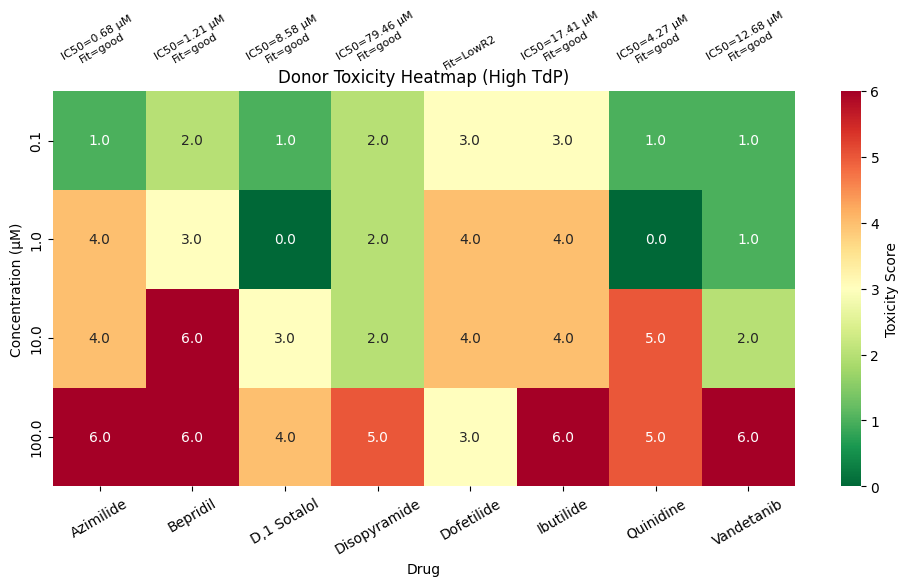

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

selected_drugs = ['Bepridil','Dofetilide','Quinidine','D,1 Sotalol','Azimilide','Vandetanib','Disopyramide','Ibutilide']

df_selected = valid_df[valid_df['Drugname'].isin(selected_drugs)].copy()

# Pivot table for heatmap
heatmap_data = df_selected.pivot_table(
    index='Dose',
    columns='Drugname',
    values='vote_sum',  # aggregated toxicity
    aggfunc='sum'
)

dose_order = [0.1, 1, 10, 100]
heatmap_data = heatmap_data.reindex(dose_order).fillna(0)

# Create dictionaries for IC50 and fit quality
ec50_dict = results.groupby('Drugname')['IC50'].first().to_dict()
fit_quality_dict = results.groupby('Drugname')['FitQuality'].first().to_dict()

plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',  # float formatting
    cmap='RdYlGn_r',
    cbar_kws={'label': 'Toxicity Score'}
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')

# Annotate IC50 only if FitQuality is "good"
for i, drug in enumerate(heatmap_data.columns):
    ic50_value = ec50_dict.get(drug, None)
    fit_val = fit_quality_dict.get(drug, None)

    label_text = ""
    if fit_val == "good" and ic50_value is not None and not np.isnan(ic50_value):
        label_text = f"IC50={ic50_value:.2f} µM\nFit={fit_val}"
    elif fit_val is not None:
        label_text = f"Fit={fit_val}"

    if label_text:
        ax.text(
            i + 0.5,
            -0.2,  # slightly above heatmap
            label_text,
            ha='center',
            va='bottom',
            fontsize=8,
            color='black',
            rotation=30,
            transform=ax.transData
        )

plt.title("Donor Toxicity Heatmap (High TdP)")
plt.ylabel("Concentration (µM)")
plt.xlabel("Drug")
plt.tight_layout()
plt.show()


safety margin

In [ ]:
import pandas as pd
import math

# Lists of drugs
high_drugs = ['Bepridil','Dofetilide','Quinidine','D,1 Sotalol','Azimilide','Vandetanib','Disopyramide','Ibutilide']
med_drugs = ['Terfenadine','Ondansetron',
             'Astemizole','Clarithromycin','Clozapine','Domperidone',
             'Droperidol','Risperidone']
low_drugs = ['Mexiletine','Ranolazine','Verapamil','Loratadine','Nifedipine','Nitrendipine']

all_tdp = high_drugs + med_drugs + low_drugs

c_max = [0.031500,0.002100,0.842900,14.686400,0.396000,4.260000,6.400000,0.140000,
         0.000300,0.358500,0.007800,1.200000,0.085670,0.050000,0.372000,0.040400,
         2.503200,1.948200,0.045000,0.000176,0.338000,0.110000]

cell_line = 'autoencoder'
rows = []

for i, drug in enumerate(all_tdp):
    drug_result = results[(results['Drugname'] == drug) & (results['FitQuality'] == 'good')]

    if not drug_result.empty:
        ic50 = drug_result['IC50'].values[0]
        safety_margin = math.log10(ic50 / c_max[i])
        print(f"{drug}: IC50={ic50:.4g}, Cmax={c_max[i]}, Safety margin (log10)= {safety_margin:.3f}")

        rows.append([drug, ic50, cell_line, safety_margin])
    else:
        print(f"{drug}: no good fit, skipped")

mos_df = pd.DataFrame(rows, columns=['Compound', 'ec50','cell.line', 'safety.margin'])
mos_df


Bepridil: IC50=1.207, Cmax=0.0315, Safety margin (log10)= 1.584
Dofetilide: no good fit, skipped
Quinidine: IC50=4.27, Cmax=0.8429, Safety margin (log10)= 0.705
D,1 Sotalol: IC50=8.584, Cmax=14.6864, Safety margin (log10)= -0.233
Azimilide: IC50=0.6764, Cmax=0.396, Safety margin (log10)= 0.232
Vandetanib: IC50=12.68, Cmax=4.26, Safety margin (log10)= 0.474
Disopyramide: IC50=79.46, Cmax=6.4, Safety margin (log10)= 1.094
Ibutilide: IC50=17.41, Cmax=0.14, Safety margin (log10)= 2.095
Terfenadine: no good fit, skipped
Ondansetron: IC50=11.78, Cmax=0.3585, Safety margin (log10)= 1.517
Astemizole: IC50=1, Cmax=0.0078, Safety margin (log10)= 2.108
Clarithromycin: IC50=0.08526, Cmax=1.2, Safety margin (log10)= -1.148
Clozapine: no good fit, skipped
Domperidone: IC50=11.27, Cmax=0.05, Safety margin (log10)= 2.353
Droperidol: IC50=2.266, Cmax=0.372, Safety margin (log10)= 0.785
Risperidone: IC50=10, Cmax=0.0404, Safety margin (log10)= 2.394
Mexiletine: IC50=8.584, Cmax=2.5032, Safety margin (lo

,Compound,ec50,cell.line,safety.margin
0,Bepridil,1.207295,autoencoder,1.583503
1,Quinidine,4.270304,autoencoder,0.704683
2,"D,1 Sotalol",8.583711,autoencoder,-0.233240
3,Azimilide,0.676381,autoencoder,0.232496
4,Vandetanib,12.676222,autoencoder,0.473580
5,Disopyramide,79.456298,autoencoder,1.093948
6,Ibutilide,17.407235,autoencoder,2.094602
7,Ondansetron,11.775948,autoencoder,1.516507
8,Astemizole,1.000000,autoencoder,2.107905
9,Clarithromycin,0.085265,autoencoder,-1.148411


donor 1118 (unseen donor testing)

In [ ]:
donor_1118 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/all_plate_signals_1118.csv')
donor_1118

,Unnamed: 0,File,Drugname,Dose,Well,Donor,Plate,Group,0,1,...,790,791,792,793,794,795,796,797,798,799
0,0,N-Nitrosopyrrolidine_100uM,N-Nitrosopyrrolidine,100.0,B2,1118,1,treated,1250,1259,...,1249,1249,1273,1254,1233,1245,1247,1250,1223,1235
1,1,Isoniazid_100uM,Isoniazid,100.0,B3,1118,1,treated,1183,1837,...,2124,2075,2010,1702,1465,1345,1302,1272,1230,1227
2,2,Methotrexate_100uM,Methotrexate,100.0,B4,1118,1,treated,1227,1230,...,1252,1262,1263,1251,1257,1260,1229,1258,1232,1243
3,3,2-Chloroethanol_100uM,2-Chloroethanol,100.0,B5,1118,1,treated,2057,2068,...,1188,1211,1202,1197,1211,2056,2171,2176,2111,1942
4,4,Dicrotophos_100uM,Dicrotophos,100.0,B6,1118,1,treated,1295,1303,...,1364,1382,1356,1358,1352,1363,1381,1367,1355,1345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4923,4923,Pyrimethanil (Replicate)_0.1uM,Pyrimethanil (Replicate),0.1,O19,1118,16,treated,1234,1216,...,1594,1416,1360,1277,1267,1259,1244,1231,1198,1255
4924,4924,Coumarin (Replicate)_0.1uM,Coumarin (Replicate),0.1,O20,1118,16,treated,1415,1376,...,2262,1873,1659,1534,1467,1454,1436,1401,1391,1384
4925,4925,Fenthion (Replicate)_0.1uM,Fenthion (Replicate),0.1,O21,1118,16,treated,1456,1440,...,1461,1447,1634,2565,2737,2876,2783,2640,2217,1874
4926,4926,Chlorendic acid (Replicate)_0.1uM,Chlorendic acid (Replicate),0.1,O22,1118,16,treated,1357,1326,...,1428,1454,1494,2145,2344,2485,2494,2435,2271,1922


In [ ]:
X_treated = donor_1118.iloc[:, 207:607].to_numpy() # jsut the signal
X_treated = X_treated.reshape(X_treated.shape[0], -1)

from sklearn import preprocessing
min_max_scaler = preprocessing.MinMaxScaler()
X_treated = min_max_scaler.fit_transform(X_treated)


In [ ]:
avg_nrmse = window_nrmse_all(X_treated, 50)
avg_nrmse

/tmp/ipykernel_626/2526773911.py:21: RuntimeWarning: divide by zero encountered in scalar divide
  normalized_rmse = rmse / window_range
/tmp/ipykernel_626/2526773911.py:21: RuntimeWarning: divide by zero encountered in scalar divide
  normalized_rmse = rmse / window_range
/tmp/ipykernel_626/2526773911.py:21: RuntimeWarning: divide by zero encountered in scalar divide
  normalized_rmse = rmse / window_range
/tmp/ipykernel_626/2526773911.py:21: RuntimeWarning: divide by zero encountered in scalar divide
  normalized_rmse = rmse / window_range
/tmp/ipykernel_626/2526773911.py:21: RuntimeWarning: divide by zero encountered in scalar divide
  normalized_rmse = rmse / window_range
/tmp/ipykernel_626/2526773911.py:21: RuntimeWarning: divide by zero encountered in scalar divide
  normalized_rmse = rmse / window_range
/tmp/ipykernel_626/2526773911.py:21: RuntimeWarning: divide by zero encountered in scalar divide
  normalized_rmse = rmse / window_range
/tmp/ipykernel_626/2526773911.py:21: Runt

[np.float64(0.8362144154459472),
 np.float64(0.1639675392037504),
 np.float64(0.5982003996901707),
 np.float64(0.36163636294743595),
 np.float64(0.7111775979179148),
 np.float64(0.8455584361807198),
 np.float64(0.8034862398102174),
 np.float64(1.169556330803978),
 np.float64(0.3937721484896626),
 np.float64(1.0929695099470211),
 np.float64(0.3872943877244024),
 np.float64(1.108316033572961),
 np.float64(0.37522581551473083),
 np.float64(0.8379409618581929),
 np.float64(1.6446319423934088),
 np.float64(0.8223355290350791),
 np.float64(0.7492578537078842),
 np.float64(1.8645013703036712),
 np.float64(0.41118623822967987),
 np.float64(0.1712878676160328),
 np.float64(0.3403900297100173),
 np.float64(1.170537209982021),
 np.float64(0.9128348778824891),
 np.float64(1.0721234992570758),
 np.float64(0.16531562963337976),
 np.float64(1.1726222386633824),
 np.float64(0.1575264454990987),
 np.float64(0.6998459584005429),
 np.float64(0.3088519609175566),
 np.float64(0.99552822727256),
 np.float64

In [ ]:
nrmse_df = pd.DataFrame(avg_nrmse, columns = ['nrmse'])
len(nrmse_df)

donor_1118_labels = donor_1118.iloc[:,:7].reset_index()
donor_1118_labels.drop('index', axis=1, inplace=True)
donor_1118_labels
donor_1118_sig = pd.DataFrame(X_treated)
donor_1118_sig
donor_1118_er_df = pd.concat([donor_1118_labels,nrmse_df,donor_1118_sig], axis = 1)
donor_1118_er_df

,Unnamed: 0,File,Drugname,Dose,Well,Donor,Plate,nrmse,0,1,...,390,391,392,393,394,395,396,397,398,399
0,0,N-Nitrosopyrrolidine_100uM,N-Nitrosopyrrolidine,100.0,B2,1118,1,0.836214,0.070772,0.077872,...,0.084388,0.079363,0.075853,0.076577,0.081394,0.078287,0.078854,0.078097,0.080087,0.079514
1,1,Isoniazid_100uM,Isoniazid,100.0,B3,1118,1,0.163968,0.073378,0.071154,...,0.184021,0.192077,0.196453,0.183813,0.169865,0.126841,0.100546,0.089137,0.081181,0.076241
2,2,Methotrexate_100uM,Methotrexate,100.0,B4,1118,1,0.598200,0.075984,0.073485,...,0.082755,0.077049,0.074625,0.073852,0.078535,0.077196,0.076126,0.074417,0.075441,0.077332
3,3,2-Chloroethanol_100uM,2-Chloroethanol,100.0,B5,1118,1,0.361636,0.078590,0.074308,...,0.071186,0.070106,0.066849,0.117455,0.196951,0.203492,0.197271,0.185771,0.153342,0.108292
4,4,Dicrotophos_100uM,Dicrotophos,100.0,B6,1118,1,0.711178,0.089288,0.084453,...,0.089833,0.090798,0.089086,0.088159,0.093099,0.090289,0.090996,0.091727,0.089108,0.088789
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4923,4923,Pyrimethanil (Replicate)_0.1uM,Pyrimethanil (Replicate),0.1,O19,1118,16,0.236315,0.076258,0.187140,...,0.204846,0.222162,0.222101,0.206431,0.186335,0.137070,0.108458,0.091999,0.080634,0.076650
4924,4924,Coumarin (Replicate)_0.1uM,Coumarin (Replicate),0.1,O20,1118,16,0.196837,0.099438,0.092542,...,0.095958,0.092023,0.095907,0.186946,0.236559,0.258320,0.255935,0.241379,0.206779,0.155483
4925,4925,Fenthion (Replicate)_0.1uM,Fenthion (Replicate),0.1,O21,1118,16,0.201024,0.106021,0.111599,...,0.108888,0.106316,0.108868,0.113094,0.249353,0.285461,0.290587,0.281178,0.253109,0.203764
4926,4926,Chlorendic acid (Replicate)_0.1uM,Chlorendic acid (Replicate),0.1,O22,1118,16,0.917849,0.095323,0.092953,...,0.095413,0.096923,0.100682,0.099741,0.173812,0.223950,0.236835,0.233202,0.224136,0.212220


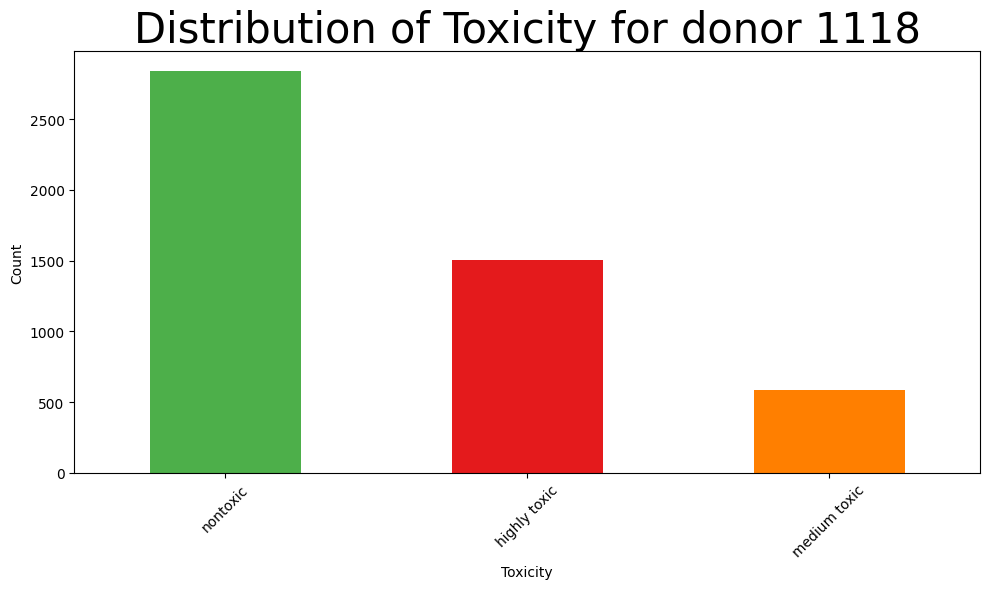

In [ ]:
donor_1118_er_df['toxicity'] = np.where(donor_1118_er_df.nrmse < category1_threshold, 'nontoxic',
                                      np.where((donor_1118_er_df.nrmse > category1_threshold) & (donor_1118_er_df.nrmse < category2_threshold),
                                               'medium toxic', 'highly toxic'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

toxicity_map = {
    'nontoxic': 2,
    'medium toxic': 4,
    'highly toxic': 0,
}

default_color_index = 2

color_palette = 'Set1'

palette = sns.color_palette(color_palette)

toxicity_counts = donor_1118_er_df['toxicity'].value_counts()

plt.figure(figsize=(10, 6))
colors = [palette[toxicity_map.get(str(toxicity), default_color_index)] for toxicity in toxicity_counts.index]
toxicity_counts.plot(kind='bar', color=colors)
plt.xlabel('Toxicity')
plt.ylabel('Count')
plt.title('Distribution of Toxicity for donor 1118',fontsize = 30)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
donor_1118_er_df

,Unnamed: 0,File,Drugname,Dose,Well,Donor,Plate,nrmse,0,1,...,391,392,393,394,395,396,397,398,399,toxicity
0,0,N-Nitrosopyrrolidine_100uM,N-Nitrosopyrrolidine,100.0,B2,1118,1,0.836214,0.070772,0.077872,...,0.079363,0.075853,0.076577,0.081394,0.078287,0.078854,0.078097,0.080087,0.079514,highly toxic
1,1,Isoniazid_100uM,Isoniazid,100.0,B3,1118,1,0.163968,0.073378,0.071154,...,0.192077,0.196453,0.183813,0.169865,0.126841,0.100546,0.089137,0.081181,0.076241,nontoxic
2,2,Methotrexate_100uM,Methotrexate,100.0,B4,1118,1,0.598200,0.075984,0.073485,...,0.077049,0.074625,0.073852,0.078535,0.077196,0.076126,0.074417,0.075441,0.077332,highly toxic
3,3,2-Chloroethanol_100uM,2-Chloroethanol,100.0,B5,1118,1,0.361636,0.078590,0.074308,...,0.070106,0.066849,0.117455,0.196951,0.203492,0.197271,0.185771,0.153342,0.108292,medium toxic
4,4,Dicrotophos_100uM,Dicrotophos,100.0,B6,1118,1,0.711178,0.089288,0.084453,...,0.090798,0.089086,0.088159,0.093099,0.090289,0.090996,0.091727,0.089108,0.088789,highly toxic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4923,4923,Pyrimethanil (Replicate)_0.1uM,Pyrimethanil (Replicate),0.1,O19,1118,16,0.236315,0.076258,0.187140,...,0.222162,0.222101,0.206431,0.186335,0.137070,0.108458,0.091999,0.080634,0.076650,nontoxic
4924,4924,Coumarin (Replicate)_0.1uM,Coumarin (Replicate),0.1,O20,1118,16,0.196837,0.099438,0.092542,...,0.092023,0.095907,0.186946,0.236559,0.258320,0.255935,0.241379,0.206779,0.155483,nontoxic
4925,4925,Fenthion (Replicate)_0.1uM,Fenthion (Replicate),0.1,O21,1118,16,0.201024,0.106021,0.111599,...,0.106316,0.108868,0.113094,0.249353,0.285461,0.290587,0.281178,0.253109,0.203764,nontoxic
4926,4926,Chlorendic acid (Replicate)_0.1uM,Chlorendic acid (Replicate),0.1,O22,1118,16,0.917849,0.095323,0.092953,...,0.096923,0.100682,0.099741,0.173812,0.223950,0.236835,0.233202,0.224136,0.212220,highly toxic


In [ ]:
all_donor_df = pd.concat([donor_1118_er_df, treated_er_df], axis = 0)
all_donor_df

,Unnamed: 0,File,Drugname,Dose,Well,Donor,Plate,nrmse,0,1,...,392,393,394,395,396,397,398,399,toxicity,Group
0,0.0,N-Nitrosopyrrolidine_100uM,N-Nitrosopyrrolidine,100.0,B2,1118,1,0.836214,0.070772,0.077872,...,0.075853,0.076577,0.081394,0.078287,0.078854,0.078097,0.080087,0.079514,highly toxic,NaN
1,1.0,Isoniazid_100uM,Isoniazid,100.0,B3,1118,1,0.163968,0.073378,0.071154,...,0.196453,0.183813,0.169865,0.126841,0.100546,0.089137,0.081181,0.076241,nontoxic,NaN
2,2.0,Methotrexate_100uM,Methotrexate,100.0,B4,1118,1,0.598200,0.075984,0.073485,...,0.074625,0.073852,0.078535,0.077196,0.076126,0.074417,0.075441,0.077332,highly toxic,NaN
3,3.0,2-Chloroethanol_100uM,2-Chloroethanol,100.0,B5,1118,1,0.361636,0.078590,0.074308,...,0.066849,0.117455,0.196951,0.203492,0.197271,0.185771,0.153342,0.108292,medium toxic,NaN
4,4.0,Dicrotophos_100uM,Dicrotophos,100.0,B6,1118,1,0.711178,0.089288,0.084453,...,0.089086,0.088159,0.093099,0.090289,0.090996,0.091727,0.089108,0.088789,highly toxic,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19399,NaN,Pyrimethanil (Replicate)_0.1uM,Pyrimethanil (Replicate),0.1,NaN,1434,16,0.164682,0.115767,0.112907,...,0.115722,0.110273,0.105119,0.106324,0.102739,0.104366,0.098854,0.100629,nontoxic,treated
19400,NaN,Coumarin (Replicate)_0.1uM,Coumarin (Replicate),0.1,NaN,1434,16,0.188659,0.276872,0.274440,...,0.117979,0.117817,0.126592,0.236443,0.272245,0.277007,0.274651,0.270063,nontoxic,treated
19401,NaN,Fenthion (Replicate)_0.1uM,Fenthion (Replicate),0.1,NaN,1434,16,0.201158,0.295848,0.312245,...,0.289117,0.304665,0.289638,0.280776,0.266566,0.228672,0.173152,0.158113,nontoxic,treated
19402,NaN,Chlorendic acid (Replicate)_0.1uM,Chlorendic acid (Replicate),0.1,NaN,1434,16,0.381908,0.083291,0.085794,...,0.145311,0.165724,0.167541,0.167815,0.165089,0.156613,0.148092,0.127799,medium toxic,treated


In [ ]:
from google.colab import files

all_donor_df.to_csv("all_donor_df.csv", index=False)
files.download("all_donor_df.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>